In [24]:
import torch

In [25]:
#Ver si tenemos cuda disponible
torch.cuda.is_available()

True

In [26]:
torch.cuda.get_device_name(0)

'NVIDIA GeForce RTX 3060 Laptop GPU'

In [27]:
!nvidia-smi

Wed Jul  1 15:46:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 596.08                 Driver Version: 596.08         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   53C    P5             17W /  129W |    3934MiB /   6144MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

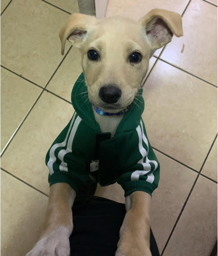

In [28]:
from PIL import Image
img = Image.open("data/cats_dogs/snoopy.png")
img

In [29]:
from torchvision.models import resnet50 #Red neuronal preentrenada
model = resnet50(weights="IMAGENET1K_V1")
#model.eval()

In [30]:
from torchvision import transforms #Concatena transformaciones para preparar los datos
from torchvision.datasets import ImageFolder #Scanear una carpeta de imagenes
from torch.utils.data import DataLoader #Cargar los datos en batches, sin utilizar toda la ram
#Estas dos ya deberían conocerlas:
from torch.nn import CrossEntropyLoss #Loss function a utilizar
from torch.optim import SGD #Optimizador
import matplotlib.pyplot as plt

In [31]:
#Utilizar la transformación en ImageFolder
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [32]:
train_folder = ImageFolder("./data/cats_dogs/train", transform=transform)
val_folder = ImageFolder("./data/cats_dogs/val", transform=transform)

train_loader = DataLoader(train_folder, batch_size=32, shuffle=True)
val_loader = DataLoader(val_folder, batch_size=32, shuffle=True)
train_loader, val_loader

(<torch.utils.data.dataloader.DataLoader at 0x1b4098f5660>,
 <torch.utils.data.dataloader.DataLoader at 0x1b409952230>)

In [33]:
#Congelar capas
for params in model.parameters():
    params.requires_grad_ = False

In [34]:
#Montar modelo en gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
display(device)
model.to(device)

device(type='cuda')

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [35]:
!nvidia-smi

Wed Jul  1 15:46:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 596.08                 Driver Version: 596.08         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   52C    P5             17W /  123W |    3939MiB /   6144MiB |     53%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Replaced final layer

In [36]:
model.fc = torch.nn.Linear(2048, 2).to(device)
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Training loop

In [37]:
from torch.optim import SGD, Adam, AdamW, RMSprop, Adagrad
import seaborn as sns

In [38]:
#Definir función de entrenamiento (training loop)
def training_loop(optimizer, loss_fn, epochs = 10):
    #Inicializar pesos de la capa final
    torch.nn.init.kaiming_normal_(model.fc.weight)
    if model.fc.bias is not None:
        torch.nn.init.zeros_(model.fc.bias)
    #Probar con momentum y nesterov.
    #Investigar otros optimizadores e incorporarlos
    all_train_loss = []
    for epoch in range(epochs): #Loop de epochs
        model.train()
        print(f"Epoch {epoch+1} of {epochs}")
        total_loss = 0
        for batch_idx, (data, target) in enumerate(train_loader): #Loop de batches
            data, target = data.to(device), target.to(device) #Pasan los datos a la GPU (device)
            #Backpropagation.
            optimizer.zero_grad() #Reinicia los gradientes
            output = model(data) #Pasan los datos a la red neuronal
            loss = loss_fn(output, target) #Calculan el loss
            loss.backward() #Calculan el gradiente
            optimizer.step() #Actualizan los pesos
            total_loss += loss.item() #Sumando función de pérdida
        print(f"Loss: {total_loss/len(train_loader)}")
        all_train_loss.append(total_loss/len(train_loader))
    return all_train_loss

In [39]:
lr = 0.001
epochs = 10
loss_fn = CrossEntropyLoss() #Loss function a utilizar.
optimizer = SGD(model.parameters(), lr=lr) #Optimizador SGD.
all_train_loss_sgd = training_loop(optimizer, loss_fn, epochs)

Epoch 1 of 10
Loss: 0.9012846880488925
Epoch 2 of 10
Loss: 0.5443347096443176
Epoch 3 of 10
Loss: 0.4038094679514567
Epoch 4 of 10
Loss: 0.3202781114313338
Epoch 5 of 10
Loss: 0.2843545890516705
Epoch 6 of 10
Loss: 0.23588956395785013
Epoch 7 of 10
Loss: 0.20522171755631766
Epoch 8 of 10
Loss: 0.19168458216720158
Epoch 9 of 10
Loss: 0.16002477043204838
Epoch 10 of 10
Loss: 0.17180834296676847


In [ ]:
optimizer = SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True) #Optimizador SGD.
all_train_loss_nesterov = training_loop(optimizer, loss_fn, epochs)

Epoch 1 of 10
Loss: 0.45510829985141754
Epoch 2 of 10
Loss: 0.12407424052556355
Epoch 3 of 10
Loss: 0.03828528730405702
Epoch 4 of 10
Loss: 0.01983938842184014
Epoch 5 of 10


In [ ]:
optimizer = AdamW(model.parameters(), lr=lr) #Optimizador SGD.
all_train_loss_adamw = training_loop(optimizer, loss_fn, epochs)

Epoch 1 of 10
Loss: 0.8450095603863398
Epoch 2 of 10
Loss: 0.7108215126726363
Epoch 3 of 10
Loss: 0.3837633381287257
Epoch 4 of 10
Loss: 0.18724608172972998
Epoch 5 of 10
Loss: 0.09516695141792297
Epoch 6 of 10
Loss: 0.06237890633443991
Epoch 7 of 10
Loss: 0.0737255211505625
Epoch 8 of 10
Loss: 0.07353173279099995
Epoch 9 of 10
Loss: 0.04470610411630736
Epoch 10 of 10
Loss: 0.05595939006242487


Text(0, 0.5, 'Loss')

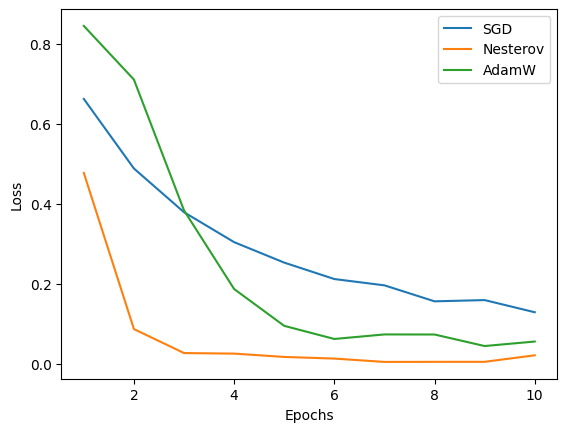

In [ ]:
sns.lineplot(x = range(1, epochs + 1), y = all_train_loss_sgd, label="SGD")
sns.lineplot(x = range(1, epochs + 1), y = all_train_loss_nesterov, label="Nesterov")
sns.lineplot(x = range(1, epochs + 1), y = all_train_loss_adamw, label="AdamW")
plt.xlabel("Epochs")
plt.ylabel("Loss")

In [ ]:
#Implementar Early Stopping.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


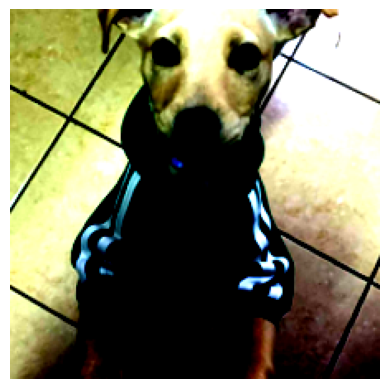

In [ ]:
import matplotlib.pyplot as plt

img_t = transform(img)
plt.imshow(img_t.permute(1, 2, 0))
plt.axis('off')
plt.show()

In [ ]:
import pandas as pd
batch = img_t.unsqueeze(0).to(device) #Agregar una dimension extra para que sean batches
logits = model(batch) #Evaluar el modelo
probs = torch.nn.functional.softmax(logits, dim=1) #Logits -> Probabilidades
pd.DataFrame(probs.cpu().detach().numpy(), columns=["cat", "dog"]) #Dataframe de probabilidades

,cat,dog
0,0.233656,0.766344
